<a href="https://colab.research.google.com/github/beyzaemul/customer-churn-decision-support-system/blob/main/IBM_Projects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Oluşan Boş Değer Sayısı:", df['TotalCharges'].isnull().sum())

df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']]

Oluşan Boş Değer Sayısı: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [ ]:

df.dropna(inplace=True)

print("Yeni Veri Seti Boyutu:", df.shape)

df.info()

Yeni Veri Seti Boyutu: (7032, 21)
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBill

/tmp/ipykernel_8156/845776658.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


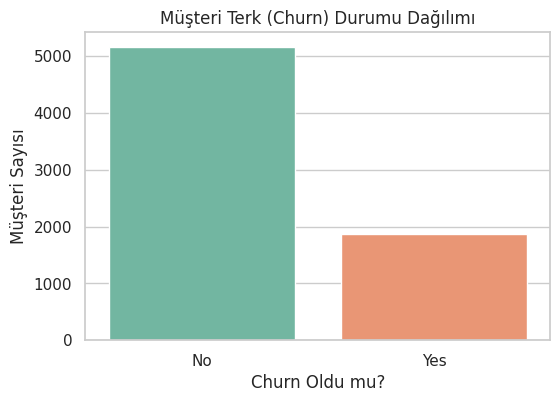

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette='Set2')

plt.title('Müşteri Terk (Churn) Durumu Dağılımı')
plt.xlabel('Churn Oldu mu?')
plt.ylabel('Müşteri Sayısı')

plt.show()

print(df['Churn'].value_counts(normalize=True) * 100)

/tmp/ipykernel_8156/937371886.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['Churn'] == 'No'], x='MonthlyCharges', shade=True, color='blue', label='Kalan Müşteriler')
/tmp/ipykernel_8156/937371886.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['Churn'] == 'Yes'], x='MonthlyCharges', shade=True, color='red', label='Terk Eden Müşteriler')


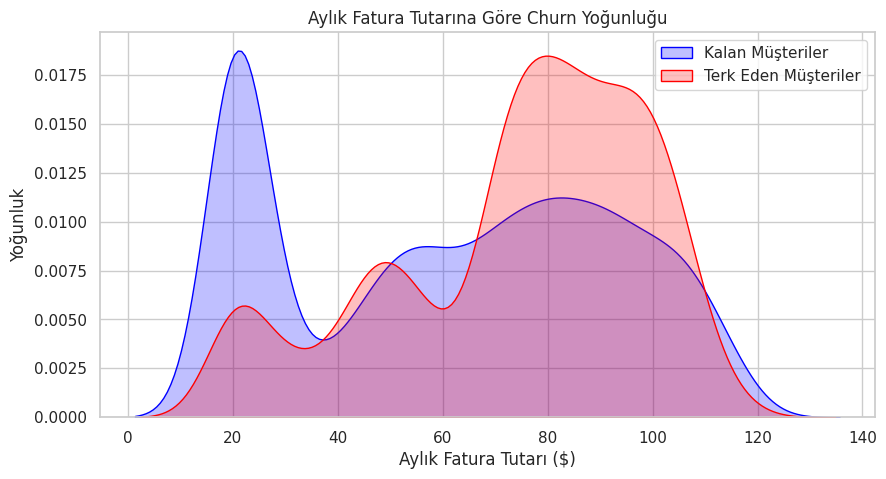

In [ ]:
plt.figure(figsize=(10, 5))

sns.kdeplot(data=df[df['Churn'] == 'No'], x='MonthlyCharges', shade=True, color='blue', label='Kalan Müşteriler')

sns.kdeplot(data=df[df['Churn'] == 'Yes'], x='MonthlyCharges', shade=True, color='red', label='Terk Eden Müşteriler')

plt.title('Aylık Fatura Tutarına Göre Churn Yoğunluğu')
plt.xlabel('Aylık Fatura Tutarı ($)')
plt.ylabel('Yoğunluk')
plt.legend()
plt.show()

/tmp/ipykernel_8156/2420240129.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette='Set1')


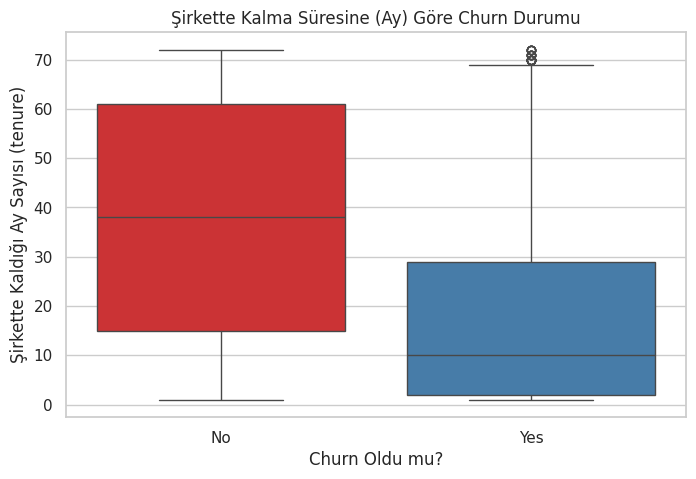

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='tenure', palette='Set1')

plt.title('Şirkette Kalma Süresine (Ay) Göre Churn Durumu')
plt.xlabel('Churn Oldu mu?')
plt.ylabel('Şirkette Kaldığı Ay Sayısı (tenure)')
plt.show()

In [ ]:

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

df_encoded = pd.get_dummies(df.drop(columns=['customerID']), drop_first=True)

df_encoded.head()

,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,29.85,29.85,0,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,1,0,34,56.95,1889.50,0,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,1,0,2,53.85,108.15,1,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,1,0,45,42.30,1840.75,0,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,0,2,70.70,151.65,1,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu:", X_test.shape)

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Yapay Zekanın Sınav Başarı Skoru (Accuracy): %{accuracy * 100:.2f}")
print("\n--- Detaylı Başarı Raporu ---")
print(classification_report(y_test, y_pred))

Eğitim seti boyutu: (5625, 30)
Test seti boyutu: (1407, 30)
Yapay Zekanın Sınav Başarı Skoru (Accuracy): %79.10

--- Detaylı Başarı Raporu ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='logloss')

xgb_model.fit(X_train_balanced, y_train_balanced)

y_pred_xgb = xgb_model.predict(X_test)

print(f"Yapay Zekanın Yeni Başarı Skoru (Accuracy): %{accuracy_score(y_test, y_pred_xgb) * 100:.2f}")
print("\n--- Yeni Geliştirilmiş Başarı Raporu ---")
print(classification_report(y_test, y_pred_xgb))

Yapay Zekanın Yeni Başarı Skoru (Accuracy): %77.26

--- Yeni Geliştirilmiş Başarı Raporu ---
              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1033
           1       0.57      0.62      0.59       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.72      1407
weighted avg       0.78      0.77      0.78      1407



In [ ]:
import pickle

with open('churn_model.pkl', 'wb') as file:
    pickle.dump(xgb_model, file)

model_columns = list(X.columns)
with open('model_columns.pkl', 'wb') as file:
    pickle.dump(model_columns, file)

print("Güncel Yapay Zeka Modeli Başarıyla Kaydedildi! 🚀")

Güncel Yapay Zeka Modeli Başarıyla Kaydedildi! 🚀


In [ ]:
!pip install fastapi uvicorn pydantic nest_asyncio

In [ ]:
%%writefile main.py
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
import pickle
import pandas as pd

app = FastAPI(title="Türk Telekom Churn Simülasyon API")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

with open('churn_model.pkl', 'rb') as file:
    model = pickle.load(file)

with open('model_columns.pkl', 'rb') as file:
    model_columns = pickle.load(file)

class CustomerData(BaseModel):
    gender: int
    SeniorCitizen: int
    tenure: int
    MonthlyCharges: float
    TotalCharges: float
    Contract_One_year: int = 0
    Contract_Two_year: int = 0
    InternetService_Fiber_optic: int = 1
    InternetService_No: int = 0

@app.post("/predict")
def predict_churn(data: CustomerData):
    input_data = data.model_dump()
    df_input = pd.DataFrame(columns=model_columns)
    df_input.loc[0] = 0

    for key, value in input_data.items():
        if key in df_input.columns:
            df_input[key] = value

    churn_probability = model.predict_proba(df_input)[0][1]
    return {"churn_risk_percentage": round(float(churn_probability) * 100, 2)}

@app.get("/")
def read_root():
    return {"status": "Türk Telekom Yapay Zeka Sunucusu Aktif! 🚀"}

Writing main.py


In [ ]:
import nest_asyncio
import uvicorn
import multiprocessing
from google.colab import output

nest_asyncio.apply()

def run_server():
    uvicorn.run(app="main:app", host="0.0.0.0", port=8000, log_level="info")

try:
    server_process.terminate()
except:
    pass

server_process = multiprocessing.Process(target=run_server)
server_process.start()

colab_url = output.serve_kernel_port_as_iframe(8000)

<IPython.core.display.Javascript object>